# RAG Verification Pipeline — Zero-Shot Health Claim Checking
**ASHO-UAB Fake News Prediction — Phase 3**

Zero-shot health claim verification using Retrieval-Augmented Generation (RAG). No fine-tuned model required.

**Pipeline:**
1. **Query distillation** — extract PubMed-friendly keywords from the claim using Llama 3
2. **Retrieve** — fetch relevant abstracts from PubMed
3. **Rerank** — score (claim, abstract) pairs with a cross-encoder and keep the top 3
4. **Verify** — classify the claim with Llama 3 (via Groq) given the retrieved evidence
5. **Evaluate** — macro F1 + ROUGE/BERTScore against PubHealth ground truth

In [20]:
!pip install biopython groq rouge-score bert-score sentence-transformers -q

## 1. Setup

In [ ]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# paths
DATA_DIR = '/kaggle/input/datasets/noasolcasale/pubhealth-gusgus127/PUBHEALTH'

# Groq client (Llama 3) 
from groq import Groq
from kaggle_secrets import UserSecretsClient

_groq_client = Groq(api_key=UserSecretsClient().get_secret('GROQ_API_KEY'))
print('Groq client ready.')

# label config (consistent with Phase 1 & 2) 
LABEL_ORDER  = ['true', 'false', 'mixture', 'unproven']
LABEL_COLORS = {'true': '#4caf50', 'false': '#f44336',
                'mixture': '#ff9800', 'unproven': '#9e9e9e'}

print('Setup complete.')

Groq client ready.
Setup complete.


In [22]:
def load_split(path):
    df = pd.read_csv(path, sep='\t')
    df.dropna(subset=['claim', 'label'], inplace=True)
    df['main_text']   = df['main_text'].fillna('')
    df['explanation'] = df['explanation'].fillna('')
    df = df[df['label'].isin(LABEL_ORDER)].reset_index(drop=True)
    return df

train_df = load_split(f'{DATA_DIR}/train.tsv')
val_df   = load_split(f'{DATA_DIR}/dev.tsv')
test_df  = load_split(f'{DATA_DIR}/test.tsv')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
test_df[['claim', 'label']].head(3)

Train: 9804 | Val: 1214 | Test: 1233


,claim,label
0,A mother revealed to her child in a letter aft...,false
1,Study says too many Americans still drink too ...,true
2,Viral image Says 80% of novel coronavirus case...,true


## 2. Retriever

We first use Llama 3 to distill each claim into a short PubMed-friendly keyword query,
then fetch the top-5 matching abstracts from PubMed via the Entrez API (free, no key needed).

In [ ]:
from Bio import Entrez
Entrez.email = 'pubhealth.rag@example.com'


def extract_pubmed_query(claim: str) -> str:
    """Distil a health claim into 3-5 PubMed-friendly keywords using Llama 3."""
    resp = _groq_client.chat.completions.create(
        model='llama-3.1-8b-instant',
        temperature=0.0,
        max_tokens=40,
        messages=[{
            'role': 'user',
            'content': (
                'Extract 3-5 medical/scientific keywords from this health claim '
                'suitable for a PubMed search query. Output only the keywords, nothing else.\n\n'
                f'Claim: {claim}'
            )
        }]
    )
    return resp.choices[0].message.content.strip()


def fetch_pubmed_abstracts(query: str, n: int = 5, retries: int = 3) -> list[dict]:
    """Search PubMed and return up to `n` abstracts."""
    for attempt in range(retries):
        try:
            search_handle = Entrez.esearch(db='pubmed', term=query, retmax=n, sort='relevance')
            pmids         = Entrez.read(search_handle).get('IdList', [])
            search_handle.close()
            if not pmids:
                return []

            fetch_handle = Entrez.efetch(db='pubmed', id=','.join(pmids),
                                         rettype='xml', retmode='xml')
            records = Entrez.read(fetch_handle)
            fetch_handle.close()

            results = []
            for rec in records.get('PubmedArticle', []):
                art      = rec['MedlineCitation']['Article']
                pmid     = str(rec['MedlineCitation']['PMID'])
                title    = str(art.get('ArticleTitle', ''))
                abstract = ' '.join(
                    str(t) for t in art.get('Abstract', {}).get('AbstractText', [])
                )
                if abstract:
                    results.append({'pmid': pmid, 'title': title, 'abstract': abstract})
            return results

        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f'  [PubMed error] {e}')
                return []


# smoke-test
sample_claim = test_df.iloc[1]['claim']
sample_query = extract_pubmed_query(sample_claim)
sample_docs  = fetch_pubmed_abstracts(sample_query, n=3)
print(f'Claim  : {sample_claim}')
print(f'Query  : {sample_query}')
print(f'Results: {len(sample_docs)}')
if sample_docs:
    print(f'  [{sample_docs[0]["pmid"]}] {sample_docs[0]["title"][:70]}')

Claim  : Study says too many Americans still drink too much.
Query  : Excessive alcohol consumption 
Alcohol use disorder 
Binge drinking 
Alcohol abuse 
Substance use
Results: 3
  [35547188] Excessive alcohol consumption and binge drinking in college students.


## 3. Reranker

A cross-encoder scores each (claim, abstract) pair and reorders results by relevance
before they reach the LLM. Model: `cross-encoder/ms-marco-MiniLM-L-6-v2` (~22M params).

In [ ]:
from sentence_transformers import CrossEncoder

_reranker = None

def get_reranker():
    global _reranker
    if _reranker is None:
        _reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)
        print('Reranker loaded.')
    return _reranker


def rerank(claim: str, docs: list[dict], top_k: int = 3) -> list[dict]:
    """Rerank docs by relevance to the original claim; return top_k."""
    if not docs:
        return docs
    scores = get_reranker().predict([(claim, d['abstract']) for d in docs])
    ranked = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    for score, doc in ranked:
        doc['rerank_score'] = float(score)
    return [doc for _, doc in ranked[:top_k]]


# smoke-test
reranked = rerank(sample_claim, sample_docs, top_k=3)
print(f'Reranked {len(sample_docs)} -> top {len(reranked)} docs')
for d in reranked:
    print(f'  score={d["rerank_score"]:.3f}  {d["title"][:65]}')

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Reranker loaded.
Reranked 3 -> top 3 docs
  score=-1.992  Effectiveness of brief alcohol interventions in primary care popu
  score=-2.471  Excessive alcohol consumption and binge drinking in college stude
  score=-6.215  [Chapters from alcohology].


## 4. Prompt Builder

In [25]:
SYSTEM_PROMPT = """You are an expert medical fact-checker with deep knowledge of clinical research and public health.
Your task is to classify health claims based on the provided medical evidence.
You must reason carefully and cite the evidence when explaining your decision.
Always output exactly the required format — no preamble, no extra text.

EXAMPLES:
Label: mixture
Explanation: While some studies support the claim's core finding, others report conflicting results depending on dosage and population studied.

Label: unproven
Explanation: No peer-reviewed evidence was found to support or refute this claim; it remains speculative without clinical trial data."""


def build_prompt(claim: str, docs: list[dict], max_chars: int = 600) -> str:
    if docs:
        evidence_lines = []
        for i, d in enumerate(docs, 1):
            snippet = d['abstract'][:max_chars].rstrip()
            if len(d['abstract']) > max_chars:
                snippet += '...'
            evidence_lines.append(
                f"Evidence [{i}] [PMID {d['pmid']}]\nTitle: {d['title']}\n{snippet}"
            )
        evidence_block = '\n\n'.join(evidence_lines)
    else:
        evidence_block = 'No evidence retrieved. Base your judgment on general medical knowledge.'

    return f"""HEALTH CLAIM:
{claim}

RETRIEVED EVIDENCE:
{evidence_block}

INSTRUCTIONS:
Based on the evidence above, classify this health claim.
Choose exactly one label from: true, false, mixture, unproven
  - true     : the claim is well-supported by evidence
  - false    : the claim is contradicted by evidence
  - mixture  : the evidence is mixed or the claim is partially correct
  - unproven : insufficient evidence to support or refute the claim

OUTPUT FORMAT (follow exactly):
Label: <label>
Explanation: <2-4 sentences citing the evidence above>"""

## 5. LLM Verifier (Llama 3.1 via Groq)

In [ ]:
_LABEL_RE = re.compile(r'label\s*:\s*(true|false|mixture|unproven)', re.I)
_EXPL_RE  = re.compile(r'explanation\s*:\s*(.+)', re.I | re.S)


def parse_llm_output(raw: str) -> tuple[str, str]:
    """Extract label and explanation from raw model output."""
    label_match = _LABEL_RE.search(raw)
    expl_match  = _EXPL_RE.search(raw)
    label       = label_match.group(1).lower() if label_match else 'unproven'
    explanation = expl_match.group(1).strip()  if expl_match  else raw.strip()
    sentences   = re.split(r'(?<=[.!?])\s+', explanation)
    return label, ' '.join(sentences[:3])


def call_llm(prompt: str, temperature: float = 0.0,
             max_tokens: int = 256, retries: int = 4, base_wait: int = 10) -> str:
    """Call Llama 3.1-8b via Groq with exponential-backoff retry on rate limits."""
    for attempt in range(retries):
        try:
            resp = _groq_client.chat.completions.create(
                model='llama-3.3-70b-versatile', # llama-3.1-8b-instant
                temperature=temperature,
                max_tokens=max_tokens,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': prompt},
                ],
            )
            return resp.choices[0].message.content
        except Exception as e:
            if '429' in str(e) and attempt < retries - 1:
                wait = base_wait * (2 ** attempt)
                print(f'    Rate limited, retrying in {wait}s...')
                time.sleep(wait)
            else:
                raise
    raise RuntimeError('Max retries exceeded')


def verify_claim(claim: str, n_retrieve: int = 5, top_k: int = 3) -> dict:
    """Full pipeline for a single claim."""
    query  = extract_pubmed_query(claim)
    docs   = fetch_pubmed_abstracts(query, n=n_retrieve)
    docs   = rerank(claim, docs, top_k=top_k) if docs else []
    prompt = build_prompt(claim, docs)
    raw    = call_llm(prompt)
    predicted, explanation = parse_llm_output(raw)
    return {'claim': claim, 'query': query, 'docs': docs,
            'predicted': predicted, 'explanation': explanation}


# smoke-test 
row    = test_df.iloc[1]
result = verify_claim(row['claim'])
print(f'Claim    : {row["claim"]}')
print(f'Query    : {result["query"]}')
print(f'Gold     : {row["label"]}  |  Predicted: {result["predicted"]}')
print(f'Evidence : {len(result["docs"])} docs')
print(f'\nExplanation:\n{result["explanation"]}')

Claim    : Study says too many Americans still drink too much.
Query    : Excessive alcohol consumption 
Alcohol use disorder 
Binge drinking 
Alcohol abuse
Gold     : true  |  Predicted: true
Evidence : 3 docs

Explanation:
The claim that too many Americans still drink too much is supported by the evidence, which highlights the significant cause of mortality, morbidity, and social problems associated with excessive drinking (Evidence [1] [PMID 29476653]). Additionally, studies on college students show a prevalence of binge drinking and excessive alcohol consumption, which can have serious health consequences (Evidence [2] [PMID 35547188] and Evidence [3] [PMID 24881329]). These findings suggest that excessive drinking remains a significant public health issue in the United States.


## 6. Demo — One Claim per Label Class

In [42]:
def render_rag_card(row: pd.Series, result: dict) -> str:
    pred_label  = result['predicted']
    true_label  = row['label']
    correct     = pred_label == true_label
    pred_col    = LABEL_COLORS.get(pred_label, '#888')
    true_col    = LABEL_COLORS.get(true_label, '#888')
    border_col  = '#4caf50' if correct else '#f44336'
    status_icon = '\u2713' if correct else '\u2717'

    evidence_html = ''
    for i, d in enumerate(result['docs'], 1):
        score = f" rerank={d.get('rerank_score', 0):.2f}" if 'rerank_score' in d else ''
        evidence_html += f"""
          <div style="margin-bottom:10px;padding:8px;background:#f5f5f5;
                      border-left:3px solid #1976d2;border-radius:3px;">
            <div style="font-size:11px;color:#555;margin-bottom:3px;">
              [{i}] PMID {d['pmid']}{score}
            </div>
            <div style="font-size:12px;color:#222;font-style:italic;">
              {d['title'][:80]}{'...' if len(d['title']) > 80 else ''}
            </div>
            <div style="font-size:12px;color:#333;margin-top:3px;">
              {d['abstract'][:250]}{'...' if len(d['abstract']) > 250 else ''}
            </div>
          </div>"""
    if not evidence_html:
        evidence_html = '<em style="color:#888">No evidence retrieved.</em>'

    gold_expl = row.get('explanation', '') or '<em style="color:#666">No explanation available.</em>'

    return f"""
    <div style="font-family:sans-serif;margin:16px 0;
                border:2px solid {border_col};border-radius:8px;
                overflow:hidden;box-shadow:0 2px 6px rgba(0,0,0,.08);">
      <div style="background:#f8f9fa;padding:10px 16px;
                  border-bottom:1px solid #eee;display:flex;align-items:center;gap:8px;">
        <span style="font-size:16px;">{status_icon}</span>
        <span style="font-size:13px;color:#333;flex:1;">
          <strong>Claim:</strong> {row['claim'][:140]}{'...' if len(row['claim']) > 140 else ''}
        </span>
        <span style="background:{pred_col};color:white;padding:3px 10px;
                     border-radius:12px;font-size:12px;margin-right:4px;">Pred: {pred_label}</span>
        <span style="background:{true_col};color:white;padding:3px 10px;
                     border-radius:12px;font-size:12px;">True: {true_label}</span>
      </div>
      <div style="display:flex;">
        <div style="flex:1.4;padding:14px 16px;border-right:1px solid #eee;background:#e3f2fd;">
          <div style="font-size:12px;font-weight:bold;color:#222;margin-bottom:8px;
                      text-transform:uppercase;letter-spacing:.5px;">
            Retrieved Evidence ({len(result['docs'])} docs)
          </div>
          {evidence_html}
        </div>
        <div style="flex:1.2;padding:14px 16px;border-right:1px solid #eee;background:#fffde7;">
          <div style="font-size:12px;font-weight:bold;color:#222;margin-bottom:8px;
                      text-transform:uppercase;letter-spacing:.5px;">LLM Explanation</div>
          <div style="font-size:13px;line-height:1.7;color:#000;">{result['explanation']}</div>
        </div>
        <div style="flex:0.9;padding:14px 16px;background:#f1f8e9;">
          <div style="font-size:12px;font-weight:bold;color:#222;margin-bottom:8px;
                      text-transform:uppercase;letter-spacing:.5px;">Gold Explanation</div>
          <div style="font-size:13px;line-height:1.7;color:#000;">{gold_expl}</div>
        </div>
      </div>
    </div>
    """


demo_rows = (
    test_df.groupby('label', group_keys=False)
           .apply(lambda g: g.sample(1, random_state=42))
           .reset_index(drop=True)
)

for _, row in demo_rows.iterrows():
    print(f'Verifying [{row["label"].upper()}]: {row["claim"][:70]}...')
    res = verify_claim(row['claim'])
    display(HTML(render_rag_card(row, res)))
    time.sleep(1)

Verifying [FALSE]: U.S. President Donald Trump tweeted in November 2009 that "Obama's han...


Verifying [MIXTURE]: Richard Durbin Says President Barack Obama’s nominees met a standard o...


Verifying [TRUE]: Jury awards more than $70M to woman in baby powder lawsuit....


Verifying [UNPROVEN]: If someone with the new coronavirus sneezes, it travels about 10 feet ...


## 7. Batch Evaluation

Set `EVAL_N` to control how many test samples to evaluate.  
100 samples takes ~5 min on the Groq free tier.

In [ ]:
EVAL_N   = 100   # set len(test_df) for full evaluation
eval_df  = test_df.sample(n=min(EVAL_N, len(test_df)), random_state=42).reset_index(drop=True)
eval_rows = []

for idx, row in eval_df.iterrows():
    if idx % 10 == 0:
        print(f'  {idx}/{len(eval_df)}...')
    try:
        res = verify_claim(row['claim'])
        eval_rows.append({
            'idx':             idx,
            'claim':           row['claim'],
            'pubmed_query':    res['query'],
            'true_label':      row['label'],
            'predicted':       res['predicted'],
            'correct':         row['label'] == res['predicted'],
            'n_docs':          len(res['docs']),
            'llm_explanation': res['explanation'],
            'gold_explanation': row['explanation'],
        })
    except Exception as e:
        print(f'  skipped idx={idx}: {e}')
    time.sleep(2)

results_df = pd.DataFrame(eval_rows)
print(f'\nProcessed {len(results_df)} / {len(eval_df)} samples.')
results_df.head(3)

  0/100...
  10/100...
  20/100...
  30/100...
  40/100...
  50/100...
  60/100...
  70/100...
  80/100...
  90/100...

Processed 100 / 100 samples.


,idx,claim,pubmed_query,true_label,predicted,correct,n_docs,llm_explanation,gold_explanation
0,0,Trump backs Fla. plan to import lower-cost med...,"Importation, Pharmaceuticals, Cost, Medication",true,mixture,False,3,While some studies suggest that importing lowe...,In a move sure to get attention in a 2020 batt...
1,1,Spanking kids can cause long-term harm: Canada...,"Child abuse, corporal punishment, long-term ef...",true,true,True,3,The evidence supports the claim that spanking ...,Spanking children can cause long-term developm...
2,2,New Portable Scanner for Breast Cancer,"Portable scanner, breast cancer, mammography",false,mixture,False,3,While some studies support the development of ...,Nowhere do we hear how far along the research ...


## 8. Classification Metrics

In [29]:
y_true   = results_df['true_label'].tolist()
y_pred   = results_df['predicted'].tolist()
macro_f1 = f1_score(y_true, y_pred, labels=LABEL_ORDER, average='macro', zero_division=0)
acc      = results_df['correct'].mean()

print(f'Macro F1 : {macro_f1:.4f}')
print(f'Accuracy : {acc:.4f}\n')
print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

Macro F1 : 0.2133
Accuracy : 0.2400

              precision    recall  f1-score   support

        true       0.88      0.28      0.42        54
       false       1.00      0.09      0.17        33
     mixture       0.15      0.45      0.22        11
    unproven       0.02      0.50      0.04         2

    accuracy                           0.24       100
   macro avg       0.51      0.33      0.21       100
weighted avg       0.82      0.24      0.31       100



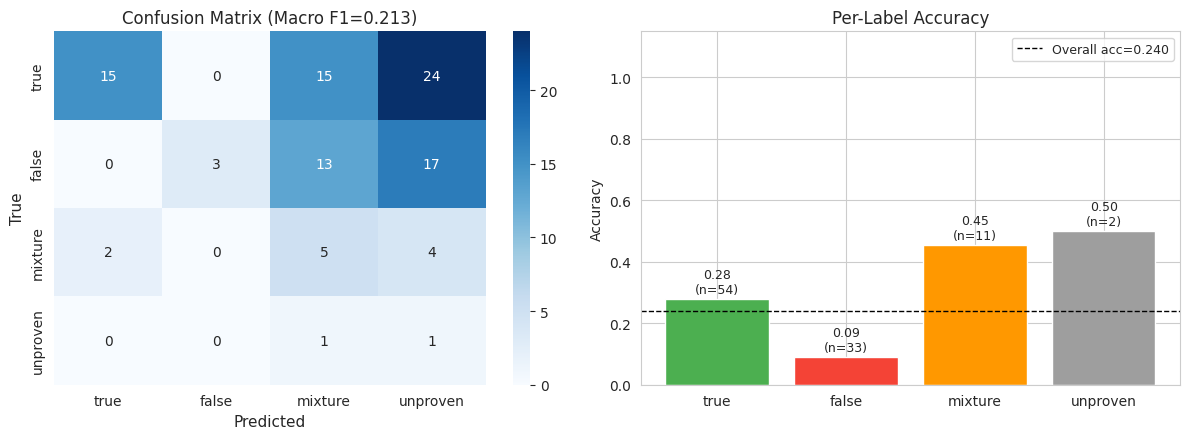

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('True',      fontsize=11)
axes[0].set_title(f'Confusion Matrix (Macro F1={macro_f1:.3f})', fontsize=12)

# per-label accuracy
per_label = (
    results_df.groupby('true_label')['correct']
              .agg(['mean', 'count'])
              .reindex(LABEL_ORDER)
)
colors = [LABEL_COLORS[l] for l in LABEL_ORDER]
bars = axes[1].bar(LABEL_ORDER, per_label['mean'], color=colors, edgecolor='white')
axes[1].axhline(acc, color='black', linestyle='--', linewidth=1,
                label=f'Overall acc={acc:.3f}')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Per-Label Accuracy', fontsize=12)
axes[1].legend(fontsize=9)
for bar, (_, r) in zip(bars, per_label.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + .02,
                 f"{r['mean']:.2f}\n(n={int(r['count'])})",
                 ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Explanation Quality — ROUGE + BERTScore

In [31]:
import torch
from rouge_score import rouge_scorer as rs
from bert_score import score as bert_score_fn

device       = 'cuda' if torch.cuda.is_available() else 'cpu'
rouge_scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# ROUGE
rouge_records = []
for _, row in results_df.iterrows():
    cand, ref = row['llm_explanation'], row['gold_explanation']
    if not ref.strip() or not cand.strip():
        rouge_records.append({'r1': 0., 'r2': 0., 'rL': 0.})
        continue
    res = rouge_scorer.score(ref, cand)
    rouge_records.append({'r1': res['rouge1'].fmeasure,
                          'r2': res['rouge2'].fmeasure,
                          'rL': res['rougeL'].fmeasure})
results_df[['r1', 'r2', 'rL']] = pd.DataFrame(rouge_records).values

# BERTScore
_, _, F = bert_score_fn(results_df['llm_explanation'].tolist(),
                        results_df['gold_explanation'].tolist(),
                        lang='en', verbose=True, device=device, batch_size=32)
results_df['bertscore_F'] = F.numpy()

# Summary
summary = results_df[['r1','r2','rL','bertscore_F']].agg(['mean','std']).T
summary.columns = ['Mean', 'Std']
summary.index   = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore-F1']
print('\n' + '='*40)
print('  RAG explanation quality')
print('='*40)
print(summary.round(4).to_string())
print('='*40)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/7 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/4 [00:00<?, ?it/s]

done in 4.56 seconds, 21.94 sentences/sec

  RAG explanation quality
                Mean     Std
ROUGE-1       0.2042  0.0922
ROUGE-2       0.0459  0.0480
ROUGE-L       0.1392  0.0703
BERTScore-F1  0.8458  0.0232


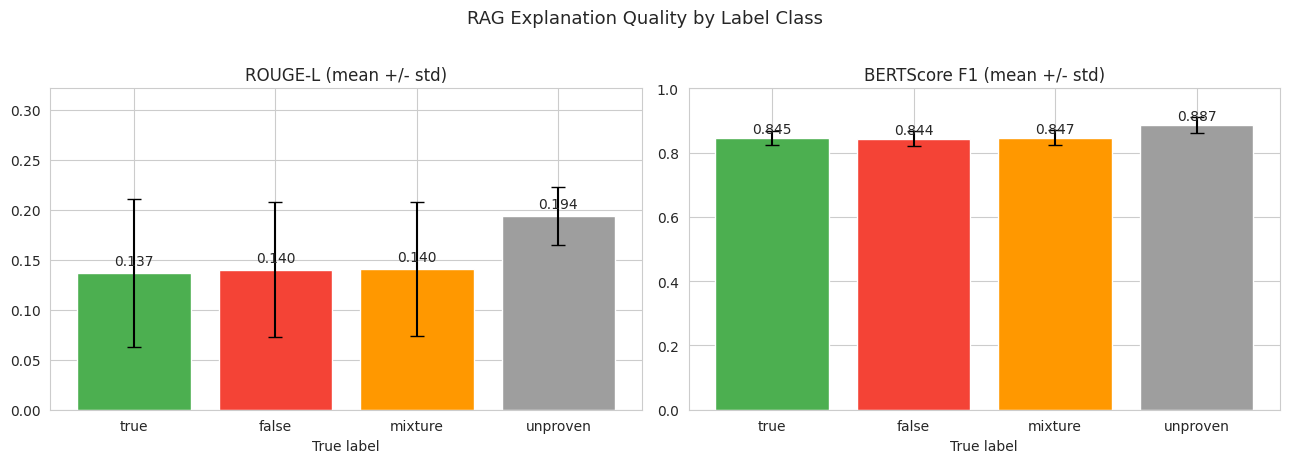

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title in zip(axes,
                              ['rL',      'bertscore_F'],
                              ['ROUGE-L', 'BERTScore F1']):
    grp   = results_df.groupby('true_label')[metric]
    means = grp.mean().reindex(LABEL_ORDER)
    stds  = grp.std().reindex(LABEL_ORDER)
    bars  = ax.bar(LABEL_ORDER, means, yerr=stds,
                   color=[LABEL_COLORS[l] for l in LABEL_ORDER],
                   capsize=5, edgecolor='white')
    ax.set_title(f'{title} (mean +/- std)', fontsize=12)
    ax.set_xlabel('True label')
    ax.set_ylim(0, min(1.0, means.max() * 1.4 + .05))
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + .005,
                f'{m:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('RAG Explanation Quality by Label Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Retrieval Analysis

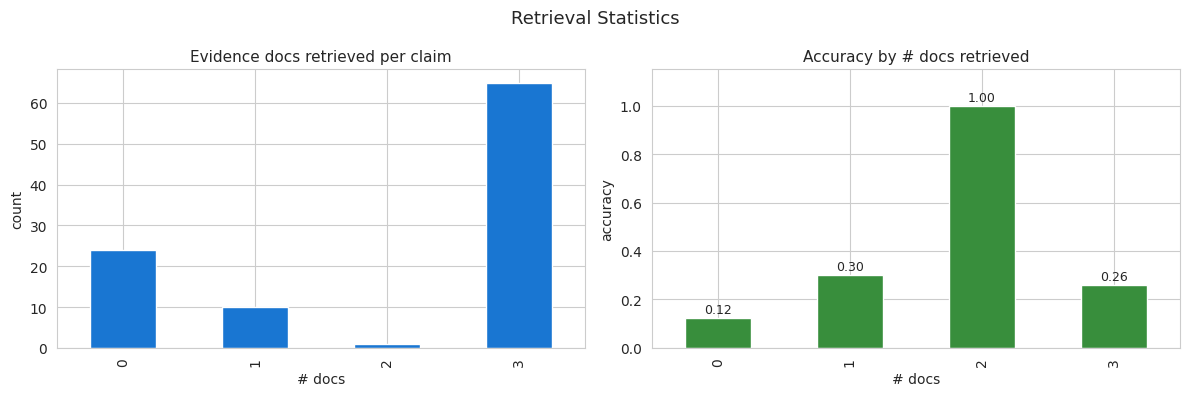

Claims with 0 docs : 24 (24.0%)
Claims with >=1 doc: 76 (76.0%)
  Accuracy (0 docs) : 0.125
  Accuracy (>=1 doc): 0.276


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df['n_docs'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#1976d2', edgecolor='white')
axes[0].set_title('Evidence docs retrieved per claim', fontsize=11)
axes[0].set_xlabel('# docs')
axes[0].set_ylabel('count')

ndoc_acc = results_df.groupby('n_docs')['correct'].mean()
ndoc_acc.plot(kind='bar', ax=axes[1], color='#388e3c', edgecolor='white')
axes[1].set_title('Accuracy by # docs retrieved', fontsize=11)
axes[1].set_xlabel('# docs')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.15)
for bar, val in zip(axes[1].patches, ndoc_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + .02,
                 f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Retrieval Statistics', fontsize=13)
plt.tight_layout()
plt.show()

no_ev = results_df[results_df['n_docs'] == 0]
wi_ev = results_df[results_df['n_docs'] >  0]
print(f"Claims with 0 docs : {len(no_ev)} ({len(no_ev)/len(results_df):.1%})")
print(f"Claims with >=1 doc: {len(wi_ev)} ({len(wi_ev)/len(results_df):.1%})")
if len(no_ev): print(f"  Accuracy (0 docs) : {no_ev['correct'].mean():.3f}")
if len(wi_ev): print(f"  Accuracy (>=1 doc): {wi_ev['correct'].mean():.3f}")

## 11. Error Analysis

In [34]:
errors = results_df[~results_df['correct']].copy()
error_pairs = (
    errors.groupby(['true_label', 'predicted'])
          .size().reset_index(name='count')
          .sort_values('count', ascending=False)
)
print(f'Total errors: {len(errors)} / {len(results_df)}\n')
print('Top error patterns (true -> predicted):')
print(error_pairs.head(10).to_string(index=False))

Total errors: 76 / 100

Top error patterns (true -> predicted):
true_label predicted  count
      true  unproven     24
     false  unproven     17
      true   mixture     15
     false   mixture     13
   mixture  unproven      4
   mixture      true      2
  unproven   mixture      1


In [35]:
cols = ['true_label','predicted','n_docs','rL','bertscore_F',
        'claim','llm_explanation','gold_explanation']
pd.set_option('display.max_colwidth', 90)
print('-- Worst 3 errors (lowest BERTScore-F1) --')
display(errors.nsmallest(3, 'bertscore_F')[cols].round(3))

-- Worst 3 errors (lowest BERTScore-F1) --


,true_label,predicted,n_docs,rL,bertscore_F,claim,llm_explanation,gold_explanation
94,true,unproven,0,0.000,0.783,Images shared in March 2020 showed a convoy of military trucks transporting bodies awa...,"No evidence was retrieved to support or refute this claim, and it is based on images r...","— Alessandro Zanoni (@AlexZan87) March 19, 2020"
79,true,unproven,0,0.029,0.802,Program Cut Catheter-Associated Urinary Tract Infections,"No evidence was retrieved to support or refute this claim, and it remains speculative ...",HealthDay highlights a national effort to help reduce an uncomfortable and costly prob...
63,false,mixture,3,0.091,0.808,Discovery offers prospect of shorter treatment and cure for chronic myelogenous leukemia,While some studies suggest that tyrosine kinase inhibitors can lead to a deep molecula...,This news release by the Dana-Farber Cancer Institute is a teaser on a potential new d...


## 12. Save Results

In [36]:
out_path = 'rag_results_test.csv'
results_df.to_csv(out_path, index=False)
print(f'Results saved -> {out_path}')

print('\n-- Phase 3 summary --')
print(f'  Macro F1 (RAG zero-shot) : {macro_f1:.4f}')
for metric, label in zip(['r1','r2','rL','bertscore_F'],
                          ['ROUGE-1','ROUGE-2','ROUGE-L','BERTScore-F1']):
    m, s = results_df[metric].mean(), results_df[metric].std()
    print(f'  {label:16s} : {m:.4f} +/- {s:.4f}')

Results saved -> rag_results_test.csv

-- Phase 3 summary --
  Macro F1 (RAG zero-shot) : 0.2133
  ROUGE-1          : 0.2042 +/- 0.0922
  ROUGE-2          : 0.0459 +/- 0.0480
  ROUGE-L          : 0.1392 +/- 0.0703
  BERTScore-F1     : 0.8458 +/- 0.0232
